# IBIS and Waste-Free SMC

This notebook compares three SMC approaches for Bayesian parameter estimation:

1. **SMC Tempering** (Del Moral et al., 2006) - baseline with adaptive tempering
2. **IBIS** (Chopin, 2002) - Iterated Batch Importance Sampling, processes data in batches
3. **Waste-Free SMC** (Dau & Chopin, 2022) - recycles all MCMC samples for improved efficiency

We apply all three methods to estimate parameters of a **Stochastic Volatility** model
and compare their efficiency in terms of ESS per unit computational cost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import sys
import time

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.smc import Tempering, IBIS, WasteFreeSMC

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T_full = len(df)

# Use first 300 observations
T = 300
y_data = y_obs[:T]
h_data = h_true[:T]

print(f'Full dataset: {T_full} observations')
print(f'Using first {T} observations')
df.head()

Full dataset: 1000 observations
Using first 300 observations


,t,h_true,y_obs
0,0,-0.811984,-0.692957
1,1,-0.705057,0.661131
2,2,-1.006561,-0.787225
3,3,-0.987188,-0.193044
4,4,-0.990092,-0.519967


## Mathematical Background

### IBIS (Iterated Batch Importance Sampling)

IBIS processes data sequentially in batches. At batch $b$:

1. **Reweight**: $w^{(i)} \leftarrow w^{(i)} \cdot p(y_{\text{new}} \mid y_{\text{old}}, \theta^{(i)})$
2. **Check ESS**: If ESS drops below threshold, resample and rejuvenate via MCMC
3. **MCMC target**: $\pi_b(\theta) \propto p(\theta) \cdot p(y_{1:b} \mid \theta)$

**Advantage**: Online processing of data as it arrives; natural for streaming applications.

### Waste-Free SMC

Standard SMC runs $K$ MCMC steps per particle but only keeps the **last** sample.
Waste-free SMC:

1. Resample $N/K$ "mother" particles (not $N$)
2. Run $K$ MCMC steps for each mother
3. **Keep ALL $K$ samples** (not just the last) = $N$ total particles
4. Reweight to correct selection bias

This effectively multiplies efficiency by $K$ at no extra computational cost.

### SMC Tempering (Baseline)

Uses likelihood tempering $\pi_t(\theta) \propto p(\theta) \cdot p(y \mid \theta)^{\gamma_t}$
with $\gamma_t \in [0, 1]$. Standard resample + $K$ MCMC moves, keeping only the last.

In [3]:
# True SV parameters
TRUE_MU = -1.0
TRUE_PHI = 0.97
TRUE_SIGMA_H = 0.15

def sv_log_likelihood(theta: np.ndarray, endog: np.ndarray) -> float:
    """Approximate log-likelihood for SV model via particle filter.

    Uses a bootstrap particle filter with N_pf particles to estimate
    p(y_{1:T} | theta).

    theta = [mu, phi, sigma_h]
    """
    mu, phi, sigma_h = theta[0], theta[1], theta[2]

    if sigma_h <= 0 or abs(phi) >= 1:
        return -np.inf

    N_pf = 200
    rng = np.random.default_rng(int(abs(hash(tuple(theta))) % (2**31)))

    endog = np.atleast_2d(endog)
    if endog.ndim == 1:
        endog = endog[:, np.newaxis]
    T_obs = endog.shape[0]

    # Initialize from stationary distribution
    if abs(phi) < 0.999:
        h_std = sigma_h / np.sqrt(1.0 - phi**2)
    else:
        h_std = sigma_h * 5.0
    h_particles = rng.normal(mu, h_std, size=N_pf)
    log_weights = np.full(N_pf, -np.log(N_pf))
    total_log_lik = 0.0

    for t in range(T_obs):
        y_t = endog[t, 0] if endog.ndim > 1 else endog[t]

        # Observation log-likelihood
        scale = np.exp(h_particles / 2.0)
        log_obs = -0.5 * np.log(2 * np.pi) - h_particles / 2.0 - 0.5 * (y_t / scale)**2

        # Incremental likelihood
        log_w = log_weights + log_obs
        max_lw = np.max(log_w)
        log_lik_inc = max_lw + np.log(np.sum(np.exp(log_w - max_lw)))
        total_log_lik += log_lik_inc

        # Normalize weights
        log_weights = log_w - log_lik_inc

        # Resample if ESS low
        w = np.exp(log_weights)
        ess = 1.0 / np.sum(w**2)
        if ess < N_pf * 0.5:
            positions = (rng.uniform() + np.arange(N_pf)) / N_pf
            cumsum = np.cumsum(w)
            indices = np.searchsorted(cumsum, positions)
            indices = np.clip(indices, 0, N_pf - 1)
            h_particles = h_particles[indices]
            log_weights = np.full(N_pf, -np.log(N_pf))

        # Propagate
        h_particles = mu + phi * (h_particles - mu) + rng.normal(0, sigma_h, N_pf)

    return total_log_lik


class SVModelForSMC:
    """SV model wrapper (BayesianModel/IBISModel protocol)."""

    def log_likelihood(self, theta: np.ndarray, endog: np.ndarray) -> float:
        return sv_log_likelihood(theta, endog)


class SVPrior:
    """Prior for SV parameters."""

    def logpdf(self, theta: np.ndarray) -> float:
        mu, phi, sigma_h = theta[0], theta[1], theta[2]
        if phi <= 0 or phi >= 1 or sigma_h <= 0:
            return -np.inf
        lp = stats.norm.logpdf(mu, loc=-1.0, scale=1.0)
        lp += stats.beta.logpdf(phi, a=20, b=1.5)
        lp += stats.halfnorm.logpdf(sigma_h, scale=0.5)
        return lp

    def sample(self, rng: np.random.Generator) -> np.ndarray:
        mu = rng.normal(-1.0, 1.0)
        phi = rng.beta(20, 1.5)
        sigma_h = abs(rng.normal(0, 0.5))
        if sigma_h < 0.01:
            sigma_h = 0.01
        return np.array([mu, phi, sigma_h])


sv_model = SVModelForSMC()
sv_prior = SVPrior()

# Test
theta_test = np.array([TRUE_MU, TRUE_PHI, TRUE_SIGMA_H])
ll = sv_log_likelihood(theta_test, y_data)
print(f'Log-likelihood at true params: {ll:.2f}')
print(f'Prior logpdf at true params: {sv_prior.logpdf(theta_test):.4f}')

Log-likelihood at true params: -1.17
Prior logpdf at true params: 1.8042


In [4]:
# Run IBIS with batch_size=50
N_PARTICLES = 1000

print('Running IBIS with batch_size=50...')
ibis = IBIS(
    model=sv_model,
    n_particles=N_PARTICLES,
    prior=sv_prior,
    n_mcmc_moves=5,
    batch_size=50,
    ess_threshold=0.5,
    seed=42,
)

endog = y_data.reshape(-1, 1)
t0 = time.time()
results_ibis = ibis.run(endog=endog)
time_ibis = time.time() - t0

results_ibis.param_names = ['mu', 'phi', 'sigma_h']
print(f'IBIS completed in {time_ibis:.1f}s')
print(f'Steps (batches): {results_ibis.n_steps}')
print(f'Log evidence: {results_ibis.log_evidence:.2f}')
print(f'Rejuvenation events: {len(results_ibis.acceptance_rates)}')
print()
print(results_ibis.summary())

Running IBIS with batch_size=50...


IBIS completed in 82.8s
Steps (batches): 6
Log evidence: -270.59
Rejuvenation events: 3

SMC Results Summary
  N particles:   1000
  K parameters:  3
  N steps:       6
  Log-evidence:  -270.5905
  Final ESS:     714.6
  Mean acc rate: 0.223

  Parameter summaries:
  Name                  Mean        Std      CI_lo      CI_hi
  -------------------------------------------------------
  mu                 -1.1219     0.2020    -1.5769    -0.7115
  phi                 0.9409     0.0446     0.8069     0.9930
  sigma_h             0.1352     0.0616     0.0477     0.2810


In [5]:
# Run Waste-Free SMC
# Need to wrap the likelihood as a target_logpdf for WasteFreeSMC
def log_target_sv(theta: np.ndarray) -> float:
    lp = sv_prior.logpdf(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + sv_log_likelihood(theta, y_data)

def log_prior_sv(theta: np.ndarray) -> float:
    return sv_prior.logpdf(theta)

def sample_prior_sv(rng: np.random.Generator) -> np.ndarray:
    return sv_prior.sample(rng)

print('Running Waste-Free SMC (k_mcmc=10)...')
wf_smc = WasteFreeSMC(
    target_logpdf=log_target_sv,
    prior_logpdf=log_prior_sv,
    prior_sample=sample_prior_sv,
    n_particles=N_PARTICLES,
    k_mcmc=10,
    ess_target_ratio=0.5,
    seed=42,
)

t0 = time.time()
results_wf = wf_smc.run()
time_wf = time.time() - t0

results_wf.param_names = ['mu', 'phi', 'sigma_h']
print(f'Waste-Free SMC completed in {time_wf:.1f}s')
print(f'Steps: {results_wf.n_steps}')
print(f'Log evidence: {results_wf.log_evidence:.2f}')
print()
print(results_wf.summary())

Running Waste-Free SMC (k_mcmc=10)...


Waste-Free SMC completed in 1.0s
Steps: 1
Log evidence: -1.52

SMC Results Summary
  N particles:   1000
  K parameters:  3
  N steps:       1
  Log-evidence:  -1.5168
  Final ESS:     880.0
  Mean acc rate: 0.208

  Parameter summaries:
  Name                  Mean        Std      CI_lo      CI_hi
  -------------------------------------------------------
  mu                 -0.7656     0.8134    -2.4588     0.8370
  phi                 0.9276     0.0540     0.8005     0.9976
  sigma_h             0.3554     0.2759     0.0187     0.9550


In [6]:
# Run SMC Tempering as baseline
print('Running SMC Tempering...')
smc_temp = Tempering(
    model=sv_model,
    prior=sv_prior,
    n_particles=N_PARTICLES,
    n_mcmc_moves=5,
    ess_target_ratio=0.5,
    seed=42,
)

t0 = time.time()
results_smc = smc_temp.run(endog=endog)
time_smc = time.time() - t0

results_smc.param_names = ['mu', 'phi', 'sigma_h']
print(f'SMC Tempering completed in {time_smc:.1f}s')
print(f'Steps: {results_smc.n_steps}')
print(f'Log evidence: {results_smc.log_evidence:.2f}')
print()
print(results_smc.summary())

Running SMC Tempering...


SMC Tempering completed in 194.7s
Steps: 4
Log evidence: -271.01

SMC Results Summary
  N particles:   1000
  K parameters:  3
  N steps:       4
  Log-evidence:  -271.0099
  Final ESS:     405.8
  Mean acc rate: 0.197

  Parameter summaries:
  Name                  Mean        Std      CI_lo      CI_hi
  -------------------------------------------------------
  mu                 -1.1221     0.1844    -1.4813    -0.7087
  phi                 0.9423     0.0418     0.8326     0.9913
  sigma_h             0.1328     0.0635     0.0439     0.2971


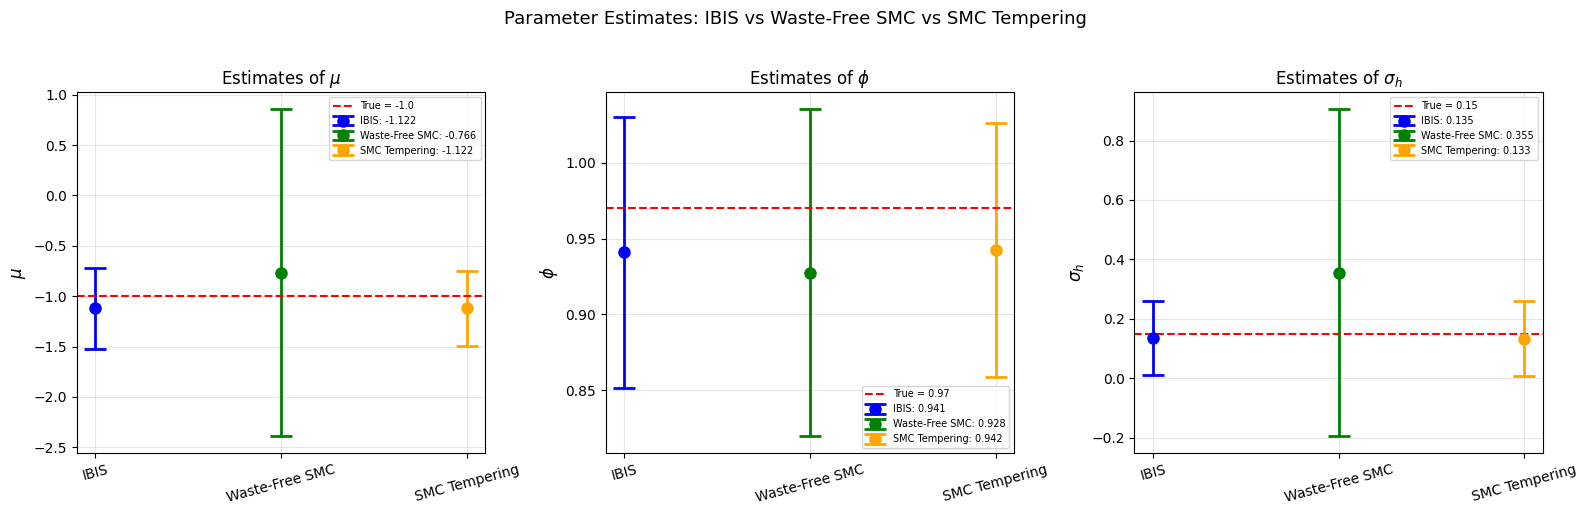

In [7]:
# Plot: Parameter estimates comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

param_labels = [r'$\mu$', r'$\phi$', r'$\sigma_h$']
true_vals = [TRUE_MU, TRUE_PHI, TRUE_SIGMA_H]

methods = {
    'IBIS': results_ibis,
    'Waste-Free SMC': results_wf,
    'SMC Tempering': results_smc,
}
colors = {'IBIS': 'blue', 'Waste-Free SMC': 'green', 'SMC Tempering': 'orange'}

for j, (ax, label, true_val) in enumerate(zip(axes, param_labels, true_vals)):
    for method_name, res in methods.items():
        samples = res.particles[:, j]
        weights = res.weights
        wmean = np.average(samples, weights=weights)
        wstd = np.sqrt(np.average((samples - wmean)**2, weights=weights))

        ax.errorbar(
            method_name, wmean, yerr=2*wstd,
            fmt='o', color=colors[method_name],
            capsize=8, capthick=2, ms=8, lw=2,
            label=f'{method_name}: {wmean:.3f}'
        )

    ax.axhline(true_val, color='red', ls='--', lw=1.5, label=f'True = {true_val}')
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Estimates of {label}')
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Parameter Estimates: IBIS vs Waste-Free SMC vs SMC Tempering', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ibis_wf_comparison_params.png', dpi=100, bbox_inches='tight')
plt.show()

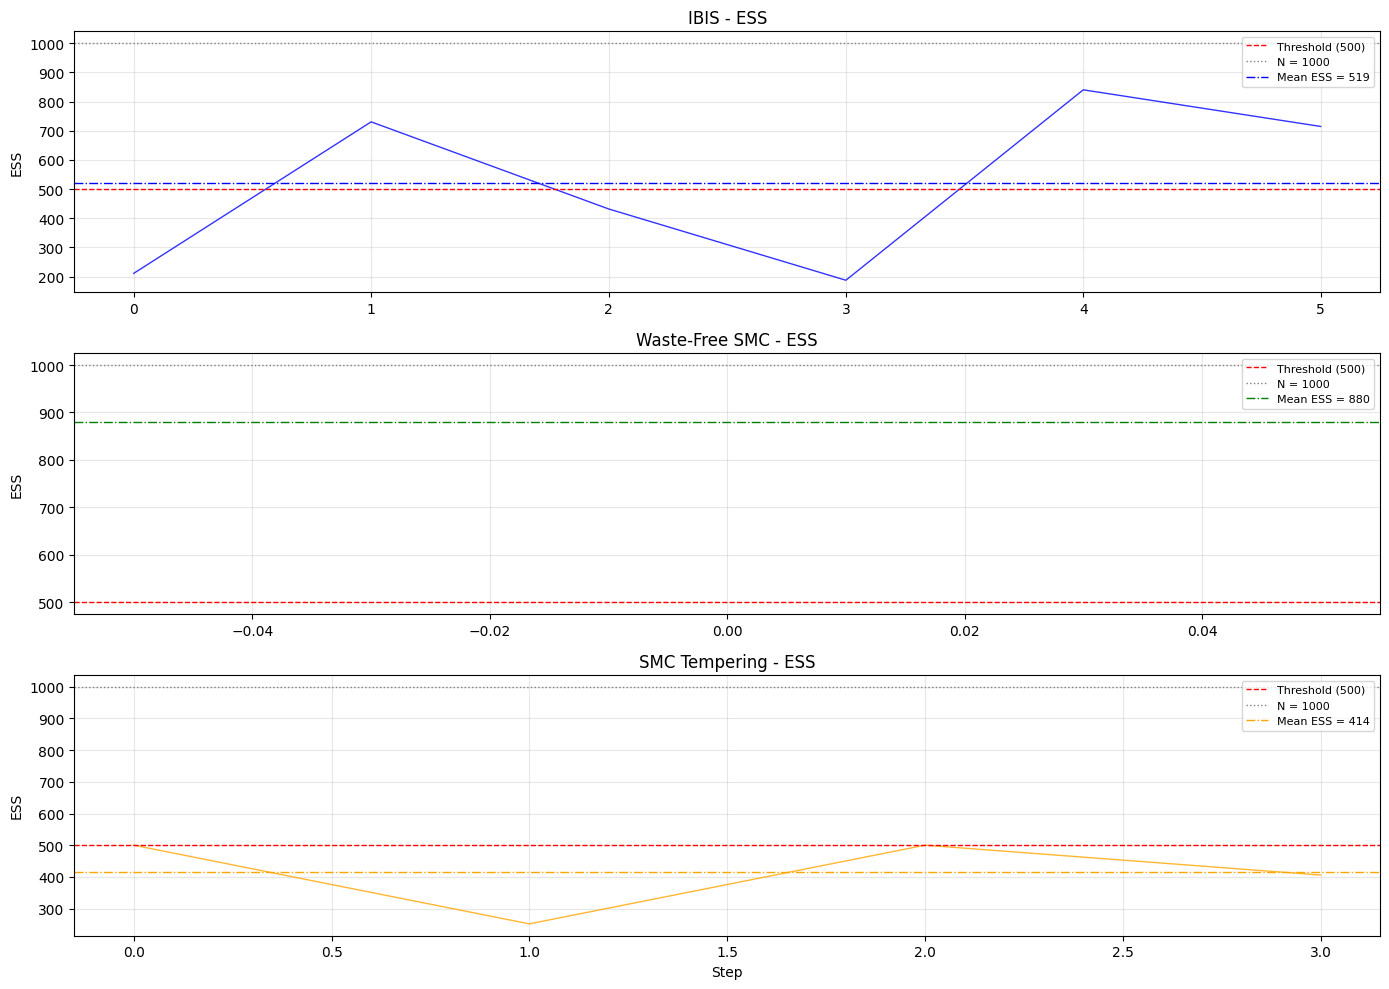

In [8]:
# Plot: ESS comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (method_name, res), color in zip(axes, methods.items(), colors.values()):
    if res.ess_history:
        ax.plot(res.ess_history, color=color, lw=1.0, alpha=0.8)
        ax.axhline(N_PARTICLES * 0.5, color='red', ls='--', lw=1,
                   label=f'Threshold ({N_PARTICLES * 0.5:.0f})')
        ax.axhline(N_PARTICLES, color='gray', ls=':', lw=1,
                   label=f'N = {N_PARTICLES}')
        mean_ess = np.mean(res.ess_history)
        ax.axhline(mean_ess, color=color, ls='-.', lw=1,
                   label=f'Mean ESS = {mean_ess:.0f}')
    ax.set_ylabel('ESS')
    ax.set_title(f'{method_name} - ESS')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Step')
plt.tight_layout()
plt.savefig('ibis_wf_comparison_ess.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
# Table: Efficiency comparison (ESS / computational cost)
print('=' * 90)
print('EFFICIENCY COMPARISON: IBIS vs Waste-Free SMC vs SMC Tempering')
print('=' * 90)

efficiency_data = []
for method_name, res, t_elapsed in [
    ('IBIS', results_ibis, time_ibis),
    ('Waste-Free SMC', results_wf, time_wf),
    ('SMC Tempering', results_smc, time_smc),
]:
    means = res.posterior_mean()
    stds = res.posterior_std()

    # Final ESS
    if res.ess_history:
        final_ess = res.ess_history[-1]
        mean_ess = np.mean(res.ess_history)
    else:
        final_ess = N_PARTICLES
        mean_ess = N_PARTICLES

    # ESS / time
    ess_per_sec = mean_ess / t_elapsed if t_elapsed > 0 else 0

    # Bias (distance from true values)
    bias = np.sqrt(np.sum((means - np.array(true_vals))**2))

    efficiency_data.append({
        'Method': method_name,
        'Time (s)': f'{t_elapsed:.1f}',
        'N Steps': res.n_steps,
        'Mean ESS': f'{mean_ess:.0f}',
        'Final ESS': f'{final_ess:.0f}',
        'ESS/sec': f'{ess_per_sec:.1f}',
        'Log Evidence': f'{res.log_evidence:.2f}',
        'RMSE(params)': f'{bias:.4f}',
        'Rejuvenations': len(res.acceptance_rates),
    })

eff_df = pd.DataFrame(efficiency_data)
print(eff_df.to_string(index=False))

print()
print('Parameter estimates by method:')
print('-' * 70)
for method_name, res in methods.items():
    means = res.posterior_mean()
    stds = res.posterior_std()
    print(f'  {method_name:20s}: mu={means[0]:.3f}({stds[0]:.3f}), '
          f'phi={means[1]:.3f}({stds[1]:.3f}), '
          f'sigma_h={means[2]:.3f}({stds[2]:.3f})')
print(f'  {"True values":20s}: mu={TRUE_MU:.3f}, phi={TRUE_PHI:.3f}, sigma_h={TRUE_SIGMA_H:.3f}')

EFFICIENCY COMPARISON: IBIS vs Waste-Free SMC vs SMC Tempering
        Method Time (s)  N Steps Mean ESS Final ESS ESS/sec Log Evidence RMSE(params)  Rejuvenations
          IBIS     82.8        6      519       715     6.3      -270.59       0.1262              3
Waste-Free SMC      1.0        1      880       880   853.8        -1.52       0.3146              1
 SMC Tempering    194.7        4      414       406     2.1      -271.01       0.1264              4

Parameter estimates by method:
----------------------------------------------------------------------
  IBIS                : mu=-1.122(0.202), phi=0.941(0.045), sigma_h=0.135(0.062)
  Waste-Free SMC      : mu=-0.766(0.813), phi=0.928(0.054), sigma_h=0.355(0.276)
  SMC Tempering       : mu=-1.122(0.184), phi=0.942(0.042), sigma_h=0.133(0.063)
  True values         : mu=-1.000, phi=0.970, sigma_h=0.150


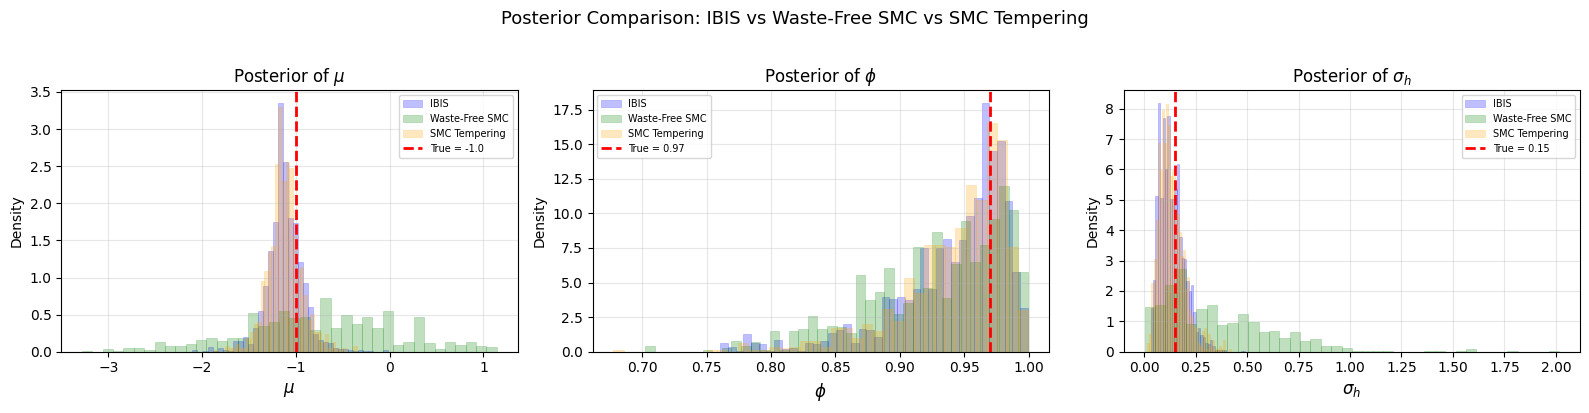

In [10]:
# Plot: Posterior density comparison (overlay)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for j, (ax, label, true_val) in enumerate(zip(axes, param_labels, true_vals)):
    for method_name, res, color in zip(
        ['IBIS', 'Waste-Free SMC', 'SMC Tempering'],
        [results_ibis, results_wf, results_smc],
        ['blue', 'green', 'orange'],
    ):
        samples = res.particles[:, j]
        weights = res.weights
        ax.hist(samples, bins=40, weights=weights, density=True,
                color=color, alpha=0.25, edgecolor=color, lw=0.5,
                label=method_name)

    ax.axvline(true_val, color='red', lw=2, ls='--', label=f'True = {true_val}')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Density')
    ax.set_title(f'Posterior of {label}')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Posterior Comparison: IBIS vs Waste-Free SMC vs SMC Tempering',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ibis_wf_posteriors.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusions: When to Use Each Approach

### SMC Tempering (Baseline)
- **Best for**: Static parameter estimation when the full dataset is available
- **Strengths**: Simple, well-understood, good for moderate-dimensional problems
- **Weaknesses**: Wastes $K-1$ MCMC evaluations per particle

### IBIS (Iterated Batch Importance Sampling)
- **Best for**: Online/streaming data, sequential model updating
- **Strengths**: Processes data incrementally; natural for real-time applications
- **Weaknesses**: Requires recomputing full likelihood at each batch; may need many rejuvenations
- **Batch size**: Larger batches = fewer rejuvenations but coarser updates

### Waste-Free SMC
- **Best for**: When MCMC evaluations are expensive (complex models)
- **Strengths**: Recycles ALL MCMC samples, multiplying effective sample size by $K$
- **Weaknesses**: Slightly more complex implementation; reweighting adds overhead
- **Key insight**: If you're already doing $K$ MCMC steps, you should keep all $K$ samples

### General Guidelines
| Scenario | Recommended Method |
|----------|-------------------|
| Full dataset available, moderate cost | SMC Tempering |
| Streaming/online data | IBIS |
| Expensive likelihood evaluations | Waste-Free SMC |
| State-space model (joint inference) | SMC$^2$ (see notebook 02) |
| Model comparison (Bayes factors) | Any SMC (all estimate log-evidence) |